# 04 — Loop de treinamento completo (dados mockados)

Objetivo: validar que o loop de treinamento roda de ponta a ponta, sem travar, sem erro de memoria, com tempo por epoca aceitavel em CPU.

O resultado (acuracia) NAO importa nesta etapa -- o modelo treinado com dados mockados nao serve para reconhecer croche real, serve apenas como prova de que o pipeline de treino funciona. Quando as fotos reais chegarem, o treino de verdade comeca do zero, usando este mesmo codigo.


## Imports

In [1]:
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import os
import matplotlib.pyplot as plt

# Reprodutibilidade.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Confirma que estamos rodando em CPU (esperado, sem GPU disponivel).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


## Dataset customizado (lê a partir dos CSVs de split)

In [2]:
class CrochetDataset(Dataset):
    """Dataset customizado que le as imagens a partir de um CSV (train.csv
    ou val.csv), em vez de varrer a pasta inteira como o ImageFolder fazia.

    Isso permite respeitar exatamente a divisao treino/validacao definida
    no notebook 03, e usar transformacoes do albumentations (que tem uma
    interface diferente do torchvision.transforms usado no notebook 01).
    """

    def __init__(self, caminho_csv, pasta_imagens, transform=None):
        self.df = pd.read_csv(caminho_csv)
        self.pasta_imagens = pasta_imagens
        self.transform = transform

        # Mapeamento fixo de classe para indice numerico -- precisa ser
        # o MESMO mapeamento em treino e validacao, senao o modelo
        # aprenderia rotulos invertidos entre os dois conjuntos.
        self.classe_para_indice = {"correto": 0, "erro": 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        linha = self.df.iloc[idx]
        nome_arquivo = linha["Arquivo"]
        classe = linha["Classe"]

        # Descobre a subpasta (correto/ ou erro/) a partir da classe,
        # ja que o CSV nao guarda o caminho completo, so o nome do arquivo.
        caminho_imagem = os.path.join(self.pasta_imagens, classe, nome_arquivo)

        # OpenCV le em BGR; convertendo para RGB para manter consistencia
        # com o que fizemos no notebook 01 e 02.
        imagem = cv2.imread(caminho_imagem)
        imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

        if self.transform:
            resultado = self.transform(image=imagem)
            imagem = resultado["image"]

        rotulo = self.classe_para_indice[classe]
        return imagem, rotulo

## Transformações (treino com augmentation, validação sem)

In [3]:
MEAN_IMAGENET = [0.485, 0.456, 0.406]
STD_IMAGENET = [0.229, 0.224, 0.225]

# Transform de TREINO: inclui as transformacoes de augmentation validadas
# no notebook 02, mas agora com probabilidade p=0.5 (em vez de p=1.0) --
# ali o objetivo era GARANTIR que a transformacao aparecesse, para fins de
# demonstracao visual; aqui, queremos que ela aconteca em ALGUMAS epocas
# e imagens, nao em todas, para gerar variedade real entre as epocas.
#
# A ordem importa: Resize primeiro (padroniza o tamanho), depois as
# transformacoes geometricas/de cor, e por fim Normalize + ToTensorV2
# (que converte para o formato que o PyTorch espera).
transform_treino = A.Compose([
    A.Resize(224, 224),
    A.Rotate(limit=180, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(1.0, 1.0), p=0.5),
    A.Normalize(mean=MEAN_IMAGENET, std=STD_IMAGENET),
    ToTensorV2(),
])

# Transform de VALIDACAO: SEM nenhuma transformacao aleatoria -- so
# resize + normalizacao. A validacao precisa refletir dados "reais",
# sem distorcao artificial, para medir honestamente o desempenho do
# modelo a cada epoca.
transform_validacao = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=MEAN_IMAGENET, std=STD_IMAGENET),
    ToTensorV2(),
])

# Instancia os datasets a partir dos CSVs gerados no notebook 03.
dataset_treino = CrochetDataset(
    caminho_csv="../dataset/train.csv",
    pasta_imagens="../dataset",
    transform=transform_treino,
)

dataset_validacao = CrochetDataset(
    caminho_csv="../dataset/val.csv",
    pasta_imagens="../dataset",
    transform=transform_validacao,
)

print(f"Imagens de treino: {len(dataset_treino)}")
print(f"Imagens de validacao: {len(dataset_validacao)}")

# DataLoaders: shuffle=True no treino (embaralha a cada epoca), shuffle=False
# na validacao (nao ha necessidade, e mante-la ordenada facilita debugar).
dataloader_treino = DataLoader(dataset_treino, batch_size=8, shuffle=True)
dataloader_validacao = DataLoader(dataset_validacao, batch_size=8, shuffle=False)

# Teste rapido de sanidade: confirma que consegue montar um batch de cada.
imagens_treino, rotulos_treino = next(iter(dataloader_treino))
print(f"Formato do batch de treino: {imagens_treino.shape}")

imagens_val, rotulos_val = next(iter(dataloader_validacao))
print(f"Formato do batch de validacao: {imagens_val.shape}")

Imagens de treino: 80
Imagens de validacao: 20
Formato do batch de treino: torch.Size([8, 3, 224, 224])
Formato do batch de validacao: torch.Size([8, 3, 224, 224])


## Definição do modelo (ResNet18 pré-treinada — transfer learning)

In [4]:
# Carrega a ResNet18 com pesos pre-treinados no ImageNet (1.000 classes).
# Na primeira execucao, isso baixa os pesos da internet (~45 MB) e guarda
# em cache local -- execucoes seguintes sao instantaneas.
modelo = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# A ResNet18 original tem uma camada final (fc = "fully connected") que
# gera 1000 saidas (uma para cada classe do ImageNet: cachorro, gato,
# carro, etc.). Nosso problema e diferente: so 2 classes (correto/erro).
#
# Por isso, substituimos APENAS essa ultima camada por uma nova, criada
# do zero, com apenas 2 saidas. Todas as camadas anteriores (que sabem
# reconhecer bordas, texturas, formas -- conhecimento generico de visao)
# permanecem com os pesos pre-treinados, intactos.
#
# in_features: numero de conexoes de entrada que a camada final espera
# (definido pela arquitetura da ResNet18, nao mudamos isso).
num_classes = 2
modelo.fc = nn.Linear(modelo.fc.in_features, num_classes)

# Move o modelo para o dispositivo correto (CPU, no nosso caso).
modelo = modelo.to(device)

print(modelo.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Linear(in_features=512, out_features=2, bias=True)


## Função de perda e otimizador

In [5]:
# CrossEntropyLoss: padrao para classificacao com 2 ou mais classes.
# Ela ja aplica internamente a funcao softmax + calculo da perda, entao
# o modelo pode devolver os "logits" brutos (sem precisar de uma camada
# de ativacao extra no final) -- e por isso a camada fc que definimos
# acima nao tem nenhuma ativacao explicita.
criterio = nn.CrossEntropyLoss()

# Adam: otimizador que ajusta a taxa de aprendizado automaticamente
# durante o treino, convergindo geralmente mais rapido e exigindo menos
# ajuste fino manual do que SGD puro -- boa escolha padrao para comecar.
#
# lr (learning rate) = 0.001 e um valor inicial comum para fine-tuning
# de redes pre-treinadas. Passamos modelo.parameters() para que o
# otimizador saiba quais pesos ele deve atualizar durante o treino.
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

print("Criterio (loss):", criterio)
print("Otimizador:", otimizador)

Criterio (loss): CrossEntropyLoss()
Otimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Loop de treinamento (5 épocas)

In [6]:
NUM_EPOCAS = 5

# Listas para guardar o historico de metricas por epoca -- serao usadas
# na proxima celula para plotar os graficos de loss/acuracia.
historico_loss_treino = []
historico_loss_validacao = []
historico_acc_treino = []
historico_acc_validacao = []

tempo_inicio_total = time.time()

for epoca in range(1, NUM_EPOCAS + 1):
    tempo_inicio_epoca = time.time()

    # ---------- FASE DE TREINO ----------
    # model.train() ativa comportamentos especificos de treino (ex:
    # dropout, se houvesse) -- na ResNet18 padrao isso afeta principalmente
    # a camada BatchNorm, que se comporta diferente em treino vs avaliacao.
    modelo.train()
    loss_acumulada = 0.0
    acertos = 0
    total = 0

    for imagens, rotulos in dataloader_treino:
        imagens = imagens.to(device)
        rotulos = rotulos.to(device)

        # Zera os gradientes acumulados do passo anterior -- necessario
        # porque o PyTorch, por padrao, ACUMULA gradientes a cada
        # chamada de .backward(), o que nao queremos aqui.
        otimizador.zero_grad()

        # Forward pass: passa o batch de imagens pelo modelo, obtendo
        # as previsoes (logits) para cada uma.
        saidas = modelo(imagens)
        loss = criterio(saidas, rotulos)

        # Backward pass: calcula os gradientes da loss em relacao a
        # cada peso do modelo.
        loss.backward()
        # Atualiza os pesos do modelo usando os gradientes calculados.
        otimizador.step()

        loss_acumulada += loss.item() * imagens.size(0)
        _, previsoes = torch.max(saidas, 1)
        acertos += (previsoes == rotulos).sum().item()
        total += rotulos.size(0)

    loss_treino = loss_acumulada / total
    acc_treino = acertos / total

    # ---------- FASE DE VALIDACAO ----------
    # model.eval() desativa comportamentos de treino (ex: BatchNorm passa
    # a usar as estatisticas acumuladas durante o treino, nao as do batch
    # atual) -- essencial para uma avaliacao consistente.
    modelo.eval()
    loss_acumulada_val = 0.0
    acertos_val = 0
    total_val = 0

    # torch.no_grad(): desativa o calculo de gradientes durante a
    # validacao -- nao precisamos disso aqui (nao vamos atualizar pesos),
    # e desativar economiza memoria e tempo de processamento.
    with torch.no_grad():
        for imagens, rotulos in dataloader_validacao:
            imagens = imagens.to(device)
            rotulos = rotulos.to(device)

            saidas = modelo(imagens)
            loss = criterio(saidas, rotulos)

            loss_acumulada_val += loss.item() * imagens.size(0)
            _, previsoes = torch.max(saidas, 1)
            acertos_val += (previsoes == rotulos).sum().item()
            total_val += rotulos.size(0)

    loss_validacao = loss_acumulada_val / total_val
    acc_validacao = acertos_val / total_val

    # Guarda as metricas desta epoca no historico.
    historico_loss_treino.append(loss_treino)
    historico_loss_validacao.append(loss_validacao)
    historico_acc_treino.append(acc_treino)
    historico_acc_validacao.append(acc_validacao)

    tempo_epoca = time.time() - tempo_inicio_epoca

    print(
        f"Epoca {epoca}/{NUM_EPOCAS} — "
        f"Loss treino: {loss_treino:.4f} | Acc treino: {acc_treino:.4f} | "
        f"Loss val: {loss_validacao:.4f} | Acc val: {acc_validacao:.4f} | "
        f"Tempo: {tempo_epoca:.1f}s"
    )

tempo_total = time.time() - tempo_inicio_total
print(f"\nTreino completo. Tempo total: {tempo_total:.1f}s ({tempo_total/60:.1f} min)")

Epoca 1/5 — Loss treino: 1.3590 | Acc treino: 0.5375 | Loss val: 1.6328 | Acc val: 0.5000 | Tempo: 6.8s
Epoca 2/5 — Loss treino: 0.6204 | Acc treino: 0.6750 | Loss val: 0.3226 | Acc val: 0.8500 | Tempo: 6.9s
Epoca 3/5 — Loss treino: 0.7196 | Acc treino: 0.7250 | Loss val: 0.5562 | Acc val: 0.8000 | Tempo: 7.0s
Epoca 4/5 — Loss treino: 0.6045 | Acc treino: 0.7000 | Loss val: 0.4557 | Acc val: 0.8000 | Tempo: 6.9s
Epoca 5/5 — Loss treino: 0.4726 | Acc treino: 0.8125 | Loss val: 0.3658 | Acc val: 0.8500 | Tempo: 6.8s

Treino completo. Tempo total: 34.5s (0.6 min)


## Visualização das métricas de treino (loss e acurácia por época)

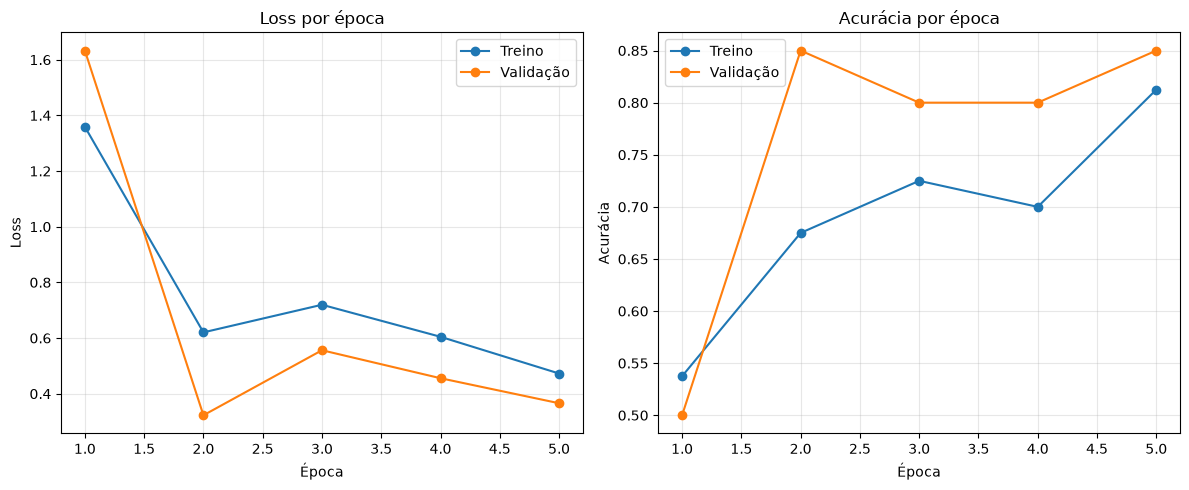

In [7]:
epocas_range = range(1, NUM_EPOCAS + 1)

plt.figure(figsize=(12, 5))

# Grafico 1: Loss (treino vs validacao)
plt.subplot(1, 2, 1)
plt.plot(epocas_range, historico_loss_treino, marker="o", label="Treino")
plt.plot(epocas_range, historico_loss_validacao, marker="o", label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss por época")
plt.legend()
plt.grid(alpha=0.3)

# Grafico 2: Acuracia (treino vs validacao)
plt.subplot(1, 2, 2)
plt.plot(epocas_range, historico_acc_treino, marker="o", label="Treino")
plt.plot(epocas_range, historico_acc_validacao, marker="o", label="Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia por época")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()